In [7]:
import torch

import xarray as xr
import numpy as np
import pandas as pd

from constants import *
from neural_net import get_net

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean

In [8]:
torch.manual_seed(10)

# Settings

In [9]:
device = torch.device("cuda:1")
dtype = torch.bfloat16

In [ ]:
batch_size = 512

# Number of ensemble members
n_ensemble = 4

# Integration steps for flow model
n_int = 20

# Forecast length: limit to available test data size minus 1 for prediction
# Test data has ~11 samples, so use max 10 lead times (6h steps = 2.5 days)
n_forecast_length = 10

lead_time_axis = pd.Timedelta("6h") * np.arange(1, n_forecast_length+1)

# Load data

In [ ]:
ds_test = xr.open_zarr("../data/sqg_test.zarr")["q"].compute()

# Estimate score for persistence

In [ ]:
initial_conditions = ds_test[:-n_forecast_length]
n_times_total = len(initial_conditions)
print(f"Test data size: {len(ds_test)}, Forecast length: {n_forecast_length}, Initial conditions: {n_times_total}")
if n_times_total <= 0:
    raise ValueError(f"Not enough test data: n_forecast_length ({n_forecast_length}) >= len(ds_test) ({len(ds_test)}). Reduce n_forecast_length.")

In [13]:
persistence_mse = []

pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]

    # Loop over lead times
    batch_mse = []
    for ld in range(1, n_forecast_length+1):
        # Get prediction
        curr_prediction = curr_initial.values

        # Error estimation
        error = curr_prediction - ds_test[start_idx+ld:start_idx+len(curr_prediction)+ld]
        mse = ((error**2) * weights_lat.numpy()).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse.append(mse)
    batch_mse = xr.concat(batch_mse, dim="lead_time")
    persistence_mse.append(batch_mse)
persistence_mse = xr.concat(persistence_mse, dim="time")

  0%|          | 0/9 [00:00<?, ?it/s]

# Deterministic forecast

## Load neural network

In [ ]:
# Load deterministic model from a checkpoint if available
# For doubly-periodic SQG single-field (q), use Transformer (from neural_net.py)
ckpt_path = "../data/best_model_test.ckpt"  # path to your trained deterministic model
try:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cfg = ckpt.get("config") if isinstance(ckpt, dict) else None
    if cfg is not None:
        print("Deterministic model config:", cfg)
        det_model = get_net(
            n_input=cfg.get("n_input", 1),
            n_output=cfg.get("n_output", 1),
            n_features=cfg.get("n_features", 64),
            n_blocks=cfg.get("n_blocks", 4),
            n_heads=cfg.get("n_heads", 8),
            mult=cfg.get("mult", 2),
            token_downsample_factor=cfg.get("token_downsample_factor", 1),
            device=device, dtype=dtype
        )
        det_model.load_state_dict(ckpt["model_state_dict"])
    else:
        # Try loading as plain state_dict into default model
        det_model = get_net(n_input=1, n_output=1, n_features=64, n_blocks=4, n_heads=8, token_downsample_factor=1, device=device, dtype=dtype)
        sd = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
        det_model.load_state_dict(sd)
    det_model = det_model.eval().to(device=device, dtype=dtype)
    print("✓ Deterministic model loaded from", ckpt_path)
except FileNotFoundError:
    print(f"⚠ Deterministic checkpoint not found at {ckpt_path}")
    print("  Skipping deterministic forecast comparison.")
    det_model = None
except Exception as e:
    print(f"⚠ Failed to load deterministic model: {e}")
    det_model = None

In [ ]:
if det_model is not None:
    det_mse = []

    pbar = tqdm(np.arange(0, n_times_total, batch_size))
    for start_idx in pbar:
        curr_initial = initial_conditions[start_idx:start_idx+batch_size]
        curr_prediction = curr_initial.values

        # Loop over lead times
        batch_mse = []
        for ld in tqdm(range(1, n_forecast_length+1), leave=False):
            # Get prediction
            net_io = torch.from_numpy(curr_prediction)
            net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
            with torch.no_grad():
                net_io = det_model(net_io).cpu().float()
            curr_prediction = curr_prediction + (net_io * res_std + res_mean).numpy()

            # Error estimation
            error = curr_prediction - ds_test[start_idx+ld:start_idx+len(curr_prediction)+ld]
            mse = ((error**2) * weights_lat.numpy()).mean(["longitude", "latitude"])
            mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
            batch_mse.append(mse)
        batch_mse = xr.concat(batch_mse, dim="lead_time")
        det_mse.append(batch_mse)
    det_mse = xr.concat(det_mse, dim="time")
else:
    print("Skipping deterministic forecast (no model available)")
    det_mse = None

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

# Flow matching forecasts

In [10]:
delta_t = 1 / n_int

def sample_with_flow(flow_model, initial_conditions):
    # Collapse the ensemble and batch dimension
    reshaped_conditions = torch.reshape(initial_conditions, (-1, *initial_conditions.shape[2:]))
    # Initialise the flow state with random noise
    dynamics = torch.randn_like(reshaped_conditions)
    # Loop through steps
    for t in np.linspace(0, 1, n_int+1)[:-1]:
        # Construct pseudo time
        pseudo_time = torch.full(
            (reshaped_conditions.shape[0], 1), t,
            device=dynamics.device, dtype=dynamics.dtype
        )

        # Concatenate flow state and initial conditions
        in_tensor = torch.cat((dynamics, reshaped_conditions), dim=1)

        # Approximate velocity
        velocity = flow_model(in_tensor, pseudo_time)

        # Make a Euler step forward
        dynamics = dynamics + delta_t * velocity
    # Get ensemble and batch dimension again
    dynamics = torch.reshape(dynamics, initial_conditions.shape)
    return dynamics

In [ ]:
# Load flow model from checkpoint and instantiate with saved config if available
ckpt = torch.load("/libre/finnt/data/teaching/flow_model.ckpt", map_location="cpu")
# Support checkpoints saved as {'model_state_dict', 'config', ...} or plain state_dict
cfg = ckpt.get("config") if isinstance(ckpt, dict) else None
if cfg is None and isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    sd = ckpt['model_state_dict']
elif cfg is None and not isinstance(ckpt, dict):
    sd = ckpt
else:
    sd = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else None
# If cfg is present, build net from it; otherwise try sensible defaults
if cfg is not None:
    print('Checkpoint config:', cfg)
    flow_model = get_net(
        n_input=cfg.get('n_input', 14),
        n_output=cfg.get('n_output', 7),
        n_features=cfg.get('n_features', 64),
        n_blocks=cfg.get('n_blocks', 4),
        n_heads=cfg.get('n_heads', 8),
        mult=cfg.get('mult', 2),
        token_downsample_factor=cfg.get('token_downsample_factor', 1),
        device=device, dtype=dtype
    )
    flow_model.load_state_dict(ckpt['model_state_dict'])
else:
    # No config: try to load state_dict into a default-sized model. If this fails,
    # inspect the checkpoint manually to infer hyperparameters.
    try:
        flow_model = get_net(n_input=14, n_output=7, n_features=64, n_blocks=4, n_heads=8, token_downsample_factor=1, device=device, dtype=dtype)
        flow_model.load_state_dict(sd)
    except Exception as e:
        print('Automatic load failed — checkpoint missing config or sizes mismatched:', e)
        raise
flow_model = flow_model.eval().to(device=device, dtype=dtype)
# Quick interface check: print forward signature to confirm pseudo-time argument is accepted
import inspect
print('flow_model.forward signature:', inspect.signature(flow_model.forward))
# Optionally compile to reduce overhead if supported
try:
    flow_model = torch.compile(flow_model, mode="reduce-overhead")
except Exception as e:
    print('torch.compile not available or failed:', e)

In [ ]:
# Smoke test: verify flow_model works with sample_with_flow on a tiny batch
print("=== Smoke Test: Flow Model Forward Pass ===")
test_batch_size = 2
test_n_ensemble = 1
test_input = torch.randn(test_n_ensemble, test_batch_size, 1, 512, 512, device=device, dtype=dtype)
print(f"Test input shape: {test_input.shape}")
try:
    with torch.no_grad():
        test_output = sample_with_flow(flow_model, test_input)
    print(f"Test output shape: {test_output.shape}")
    print("✓ Smoke test PASSED")
except Exception as e:
    print(f"✗ Smoke test FAILED: {e}")
    raise

In [12]:
flow_mse_ens = []
flow_mse_mean = []
flow_spread = []

pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]
    curr_prediction = curr_initial.values

    # Add ensemble dimension
    curr_prediction = curr_prediction[None].repeat(n_ensemble, axis=0)

    # Loop over lead times
    batch_mse_ens = []
    batch_mse_mean = []
    batch_spread = []
    for ld in tqdm(range(1, n_forecast_length+1), leave=False):
        # Get prediction
        net_io = torch.from_numpy(curr_prediction)
        net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
        with torch.no_grad():
            net_io = sample_with_flow(flow_model, net_io).cpu().float()
        curr_prediction = curr_prediction + (net_io * res_std + res_mean).numpy()

        # Error estimation for ensemble members
        truth = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld]
        truth = truth.expand_dims(ensemble=np.arange(n_ensemble), axis=0)
        error = curr_prediction - truth
        mse = ((error**2) * weights_lat.numpy()).mean(["ensemble", "longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse_ens.append(mse)

        # Error estimation for ensemble mean
        truth = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld]
        error = curr_prediction.mean(axis=0) - truth
        mse = ((error**2) * weights_lat.numpy()).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse_mean.append(mse)

        # Estimate spread as ensemble variance
        variance = curr_prediction.var(axis=0, ddof=1)
        variance = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld].copy(data=variance)
        variance = (variance * weights_lat.numpy()).mean(["longitude", "latitude"])
        variance = variance.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_spread.append(variance)

    batch_mse_ens = xr.concat(batch_mse_ens, dim="lead_time")
    flow_mse_ens.append(batch_mse_ens)

    batch_mse_mean = xr.concat(batch_mse_mean, dim="lead_time")
    flow_mse_mean.append(batch_mse_mean)

    batch_spread = xr.concat(batch_spread, dim="lead_time")
    flow_spread.append(batch_spread)

flow_mse_ens = xr.concat(flow_mse_ens, dim="time")
flow_mse_mean = xr.concat(flow_mse_mean, dim="time")
flow_spread = xr.concat(flow_spread, dim="time")

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

# Plot scores and predictions

# nRMSE

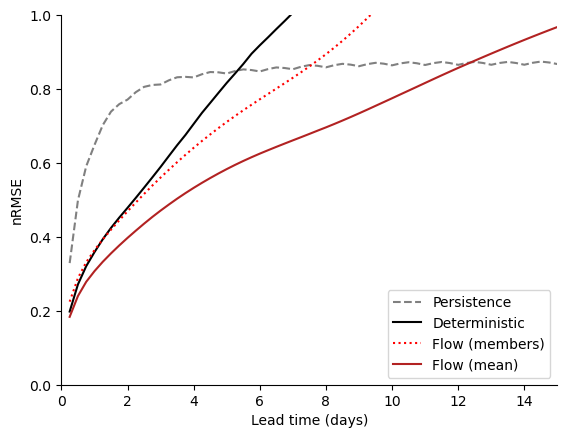

In [ ]:
fig, ax = plt.subplots(dpi=100)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position("zero")
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((persistence_mse/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
    label="Persistence", c="0.5", ls="--")

if det_mse is not None:
    ax.plot(
        lead_time_axis/pd.Timedelta("1 day"), np.sqrt((det_mse/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
        label="Deterministic", c="black", ls="-"
    )

ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((flow_mse_ens/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
    label="Flow (members)", c="red", ls=":"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((flow_mse_mean/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
    label="Flow (mean)", c="firebrick"
)

ax.set_ylabel("nRMSE")
ax.set_xlabel("Lead time (days)") 
ax.set_ylim(0, 1.)
ax.set_xlim(0, 15)

ax.legend()

## GH 500 hPa

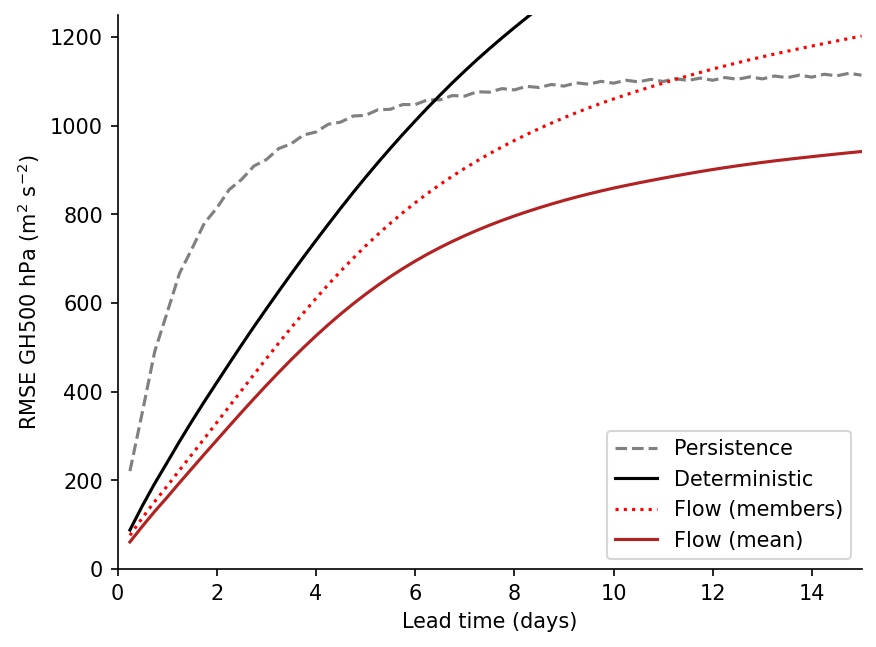

In [21]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position("zero")
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(persistence_mse.mean("time")[:, 0]),
    label="Persistence", c="0.5", ls="--"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(det_mse.mean("time")[:, 0]),
    label="Deterministic", c="black", ls="-"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(flow_mse_ens.mean("time")[:, 0]),
    label="Flow (members)", c="red", ls=":"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(flow_mse_mean.mean("time")[:, 0]),
    label="Flow (mean)", c="firebrick"
)

ax.set_ylabel("RMSE GH500 hPa (m$^2$ s$^{-2}$)")
ax.set_xlabel("Lead time (days)") 
ax.set_ylim(0, 1250.)
ax.set_xlim(0, 15)

ax.legend()

## 2-metre temperature

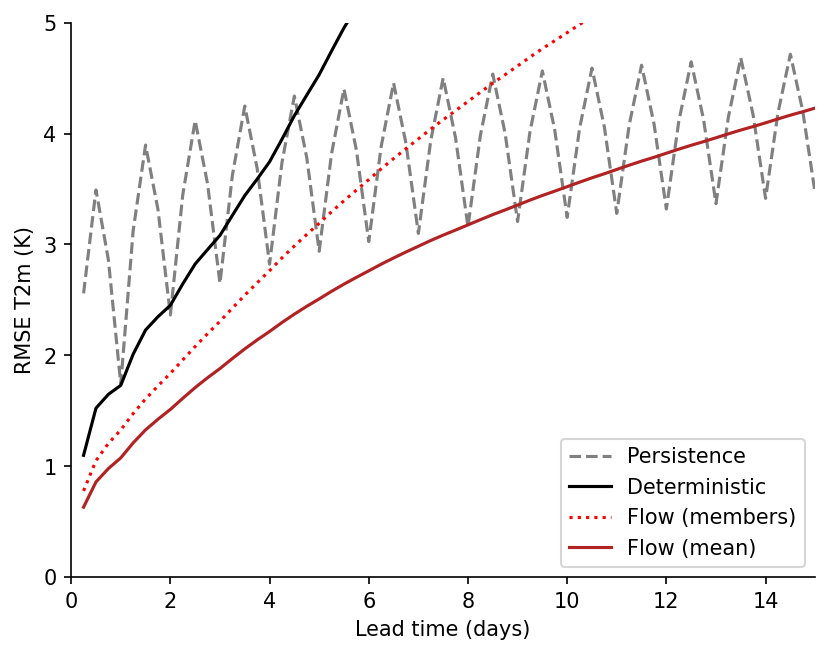

In [24]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position("zero")
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(persistence_mse.mean("time")[:, 5]),
    label="Persistence", c="0.5", ls="--"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(det_mse.mean("time")[:, 5]),
    label="Deterministic", c="black", ls="-"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(flow_mse_ens.mean("time")[:, 5]),
    label="Flow (members)", c="red", ls=":"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(flow_mse_mean.mean("time")[:, 5]),
    label="Flow (mean)", c="firebrick"
)
ax.set_ylabel("RMSE T2m (K)")
ax.set_xlabel("Lead time (days)") 
ax.set_ylim(0, 5.)
ax.set_xlim(0, 15)

ax.legend()

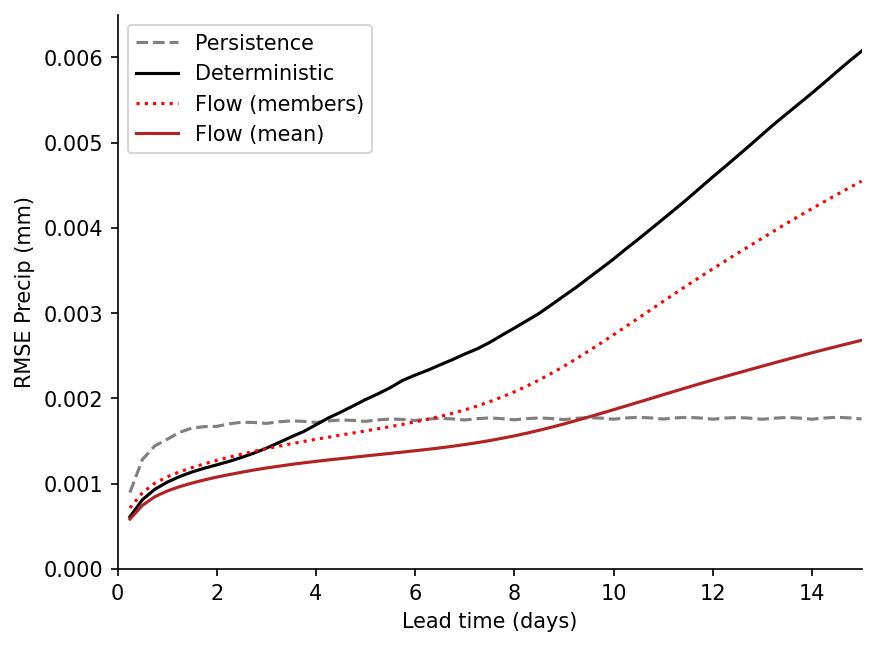

In [25]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position("zero")
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(persistence_mse.mean("time")[:, 6]),
    label="Persistence", c="0.5", ls="--"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(det_mse.mean("time")[:, 6]),
    label="Deterministic", c="black", ls="-"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(flow_mse_ens.mean("time")[:, 6]),
    label="Flow (members)", c="red", ls=":"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(flow_mse_mean.mean("time")[:, 6]),
    label="Flow (mean)", c="firebrick"
)
ax.set_ylabel("RMSE Precip (mm)")
ax.set_xlabel("Lead time (days)") 
ax.set_ylim(0, 0.0065)
ax.set_xlim(0, 15)

ax.legend()

# Plot prediction

In [57]:
start_time = "2021-12-25 00:00"
end_time = "2022-01-10 00:00"

## Deterministic

In [58]:
sliced_truth = ds_test.sel(time=slice(start_time, end_time))
det_prediction = [sliced_truth[0].values[None]]

for _ in tqdm(range(len(sliced_truth)-1)):
    net_io = torch.from_numpy(det_prediction[-1])
    net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
    with torch.no_grad():
        net_io = det_model(net_io).cpu().float()
    curr_prediction = det_prediction[-1] + (net_io * res_std + res_mean).numpy()
    det_prediction.append(curr_prediction)

det_prediction = np.concatenate(det_prediction, axis=0)
det_prediction = sliced_truth.copy(data=det_prediction)

  0%|          | 0/64 [00:00<?, ?it/s]

## Flow model

In [59]:
torch.manual_seed(42)
flow_prediction = [sliced_truth[0].values[None, None].repeat(n_ensemble, axis=0)]

for _ in tqdm(range(len(sliced_truth)-1)):
    net_io = torch.from_numpy(flow_prediction[-1])
    net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
    with torch.no_grad():
        net_io = sample_with_flow(flow_model, net_io).cpu().float()
    curr_prediction = flow_prediction[-1] + (net_io * res_std + res_mean).numpy()
    flow_prediction.append(curr_prediction)
flow_prediction = np.concatenate(flow_prediction, axis=1)
flow_prediction = sliced_truth.expand_dims(ensemble=np.arange(n_ensemble), axis=0).copy(data=flow_prediction)

  0%|          | 0/64 [00:00<?, ?it/s]

## Globe

In [64]:
member_to_plot = 1

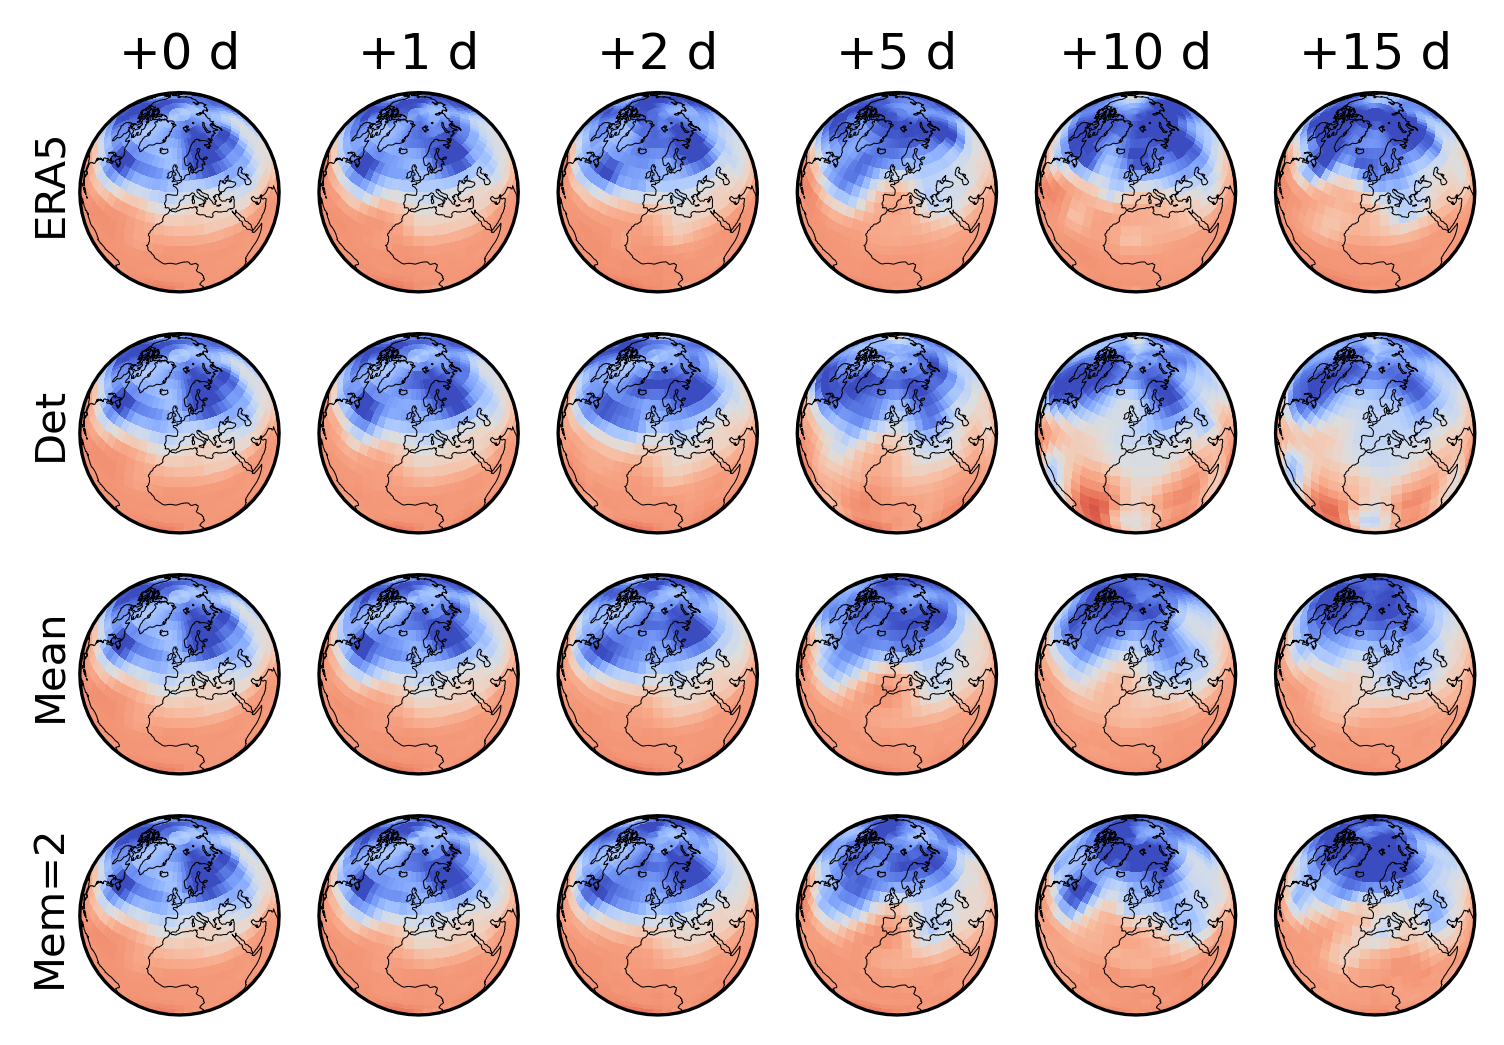

In [65]:
fig, ax = plt.subplots(
    ncols=6, nrows=4, figsize=(6, 4),
    subplot_kw={"projection": ccrs.NearsidePerspective(central_latitude=45)},
    dpi=300
)
for axi in ax:
    for axij in axi:
        axij.xaxis.set_visible(False)
        axij.yaxis.set_visible(False)
        axij.set_yticks([])
        axij.spines.left.set_visible(False)
        axij.spines.right.set_visible(False)
        axij.spines.bottom.set_visible(False)
        #axij.set_extent([-2_500_000, 2_000_000, -2_000_000, 2_500_000], ccrs.NorthPolarStereo())
        axij.add_feature(cartopy.feature.COASTLINE, zorder=98, lw=0.25)

ax[0, 0].text(x=-0.25, y=.55, s="ERA5", rotation=90, transform=ax[0, 0].transAxes, ha="left", va="center")
ax[1, 0].text(x=-0.25, y=.55, s="Det", rotation=90, transform=ax[1, 0].transAxes, ha="left", va="center")
ax[2, 0].text(x=-0.25, y=.55, s="Mean", rotation=90, transform=ax[2, 0].transAxes, ha="left", va="center")
ax[3, 0].text(x=-0.25, y=.55, s=f"Mem={member_to_plot+1:d}", rotation=90, transform=ax[3, 0].transAxes, ha="left", va="center")

for i, td in enumerate([0, 4, 8, 20, 40, 60]):
    ax[0, i].set_title("+{0:d} d".format(td//4))
    ax[0, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], sliced_truth[td, 0].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=50000, vmax=60000
    )
    ax[1, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], det_prediction[td, 0].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=50000, vmax=60000
    )
    ax[2, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[:, td, 0].mean(axis=0).T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=50000, vmax=60000
    )
    ax[3, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[member_to_plot, td, 0].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=50000, vmax=60000
    )

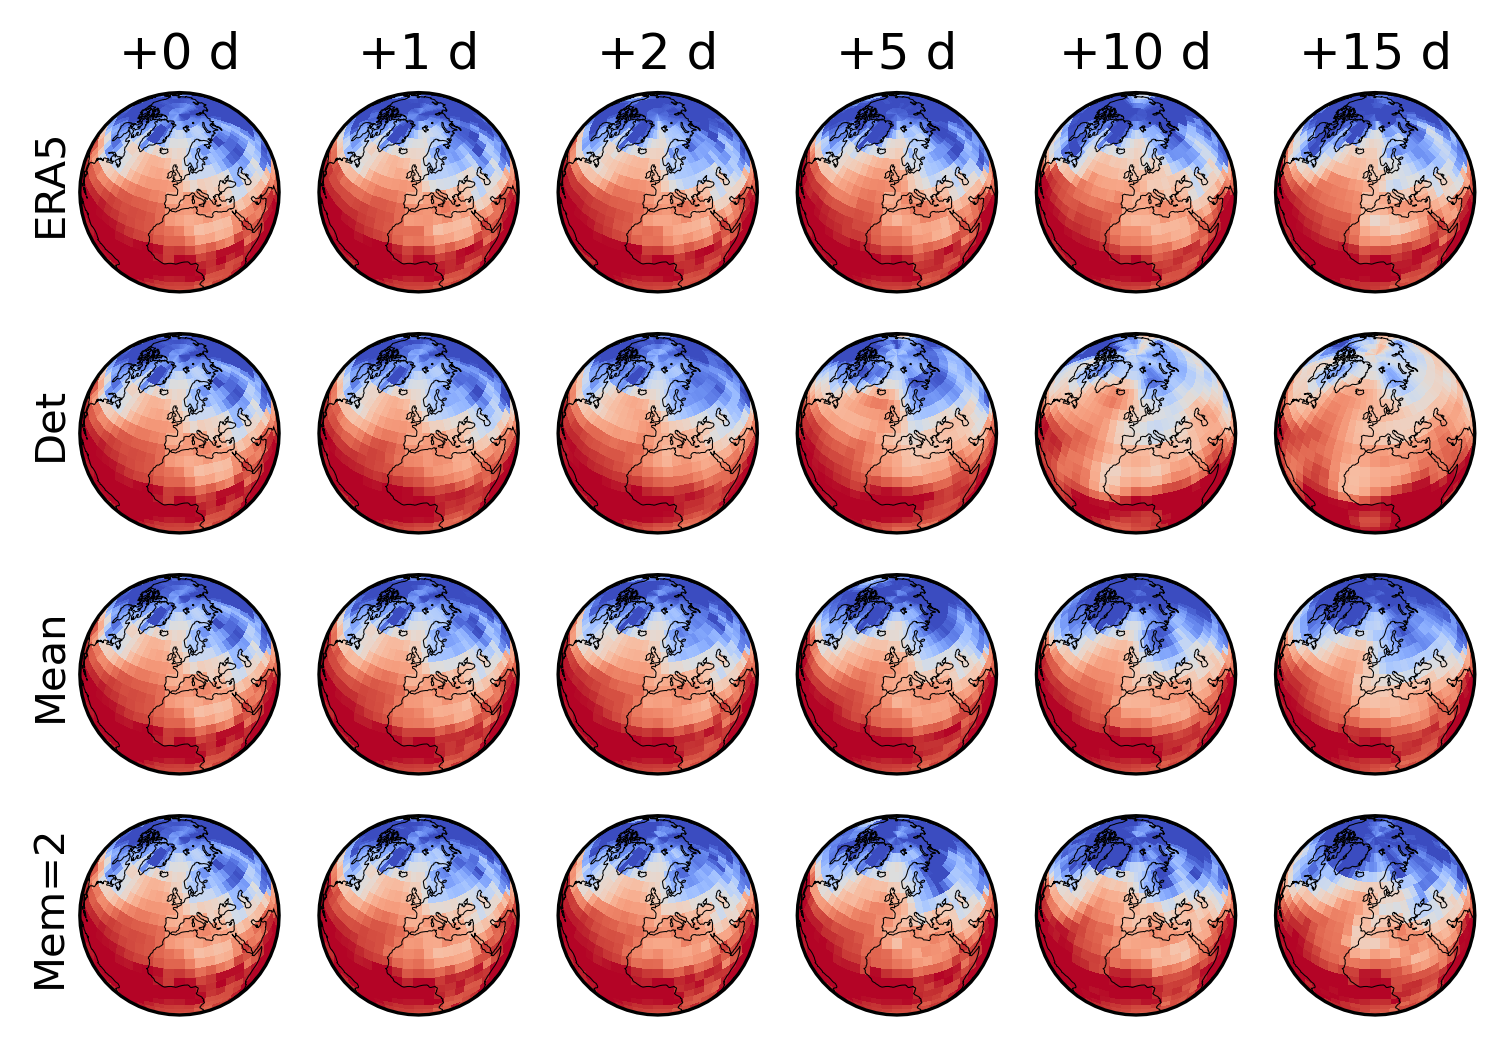

In [66]:
fig, ax = plt.subplots(
    ncols=6, nrows=4, figsize=(6, 4),
    subplot_kw={"projection": ccrs.NearsidePerspective(central_latitude=45)},
    dpi=300
)
for axi in ax:
    for axij in axi:
        axij.xaxis.set_visible(False)
        axij.yaxis.set_visible(False)
        axij.set_yticks([])
        axij.spines.left.set_visible(False)
        axij.spines.right.set_visible(False)
        axij.spines.bottom.set_visible(False)
        #axij.set_extent([-2_500_000, 2_000_000, -2_000_000, 2_500_000], ccrs.NorthPolarStereo())
        axij.add_feature(cartopy.feature.COASTLINE, zorder=98, lw=0.25)

ax[0, 0].text(x=-0.25, y=.55, s="ERA5", rotation=90, transform=ax[0, 0].transAxes, ha="left", va="center")
ax[1, 0].text(x=-0.25, y=.55, s="Det", rotation=90, transform=ax[1, 0].transAxes, ha="left", va="center")
ax[2, 0].text(x=-0.25, y=.55, s="Mean", rotation=90, transform=ax[2, 0].transAxes, ha="left", va="center")
ax[3, 0].text(x=-0.25, y=.55, s=f"Mem={member_to_plot+1:d}", rotation=90, transform=ax[3, 0].transAxes, ha="left", va="center")

for i, td in enumerate([0, 4, 8, 20, 40, 60]):
    ax[0, i].set_title("+{0:d} d".format(td//4))
    ax[0, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], sliced_truth[td, 5].T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-25, vmax=25
    )
    ax[1, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], det_prediction[td, 5].T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-25, vmax=25
    )
    ax[2, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[:, td, 5].mean(axis=0).T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-25, vmax=25
    )
    ax[3, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[member_to_plot, td, 5].T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-25, vmax=25
    )

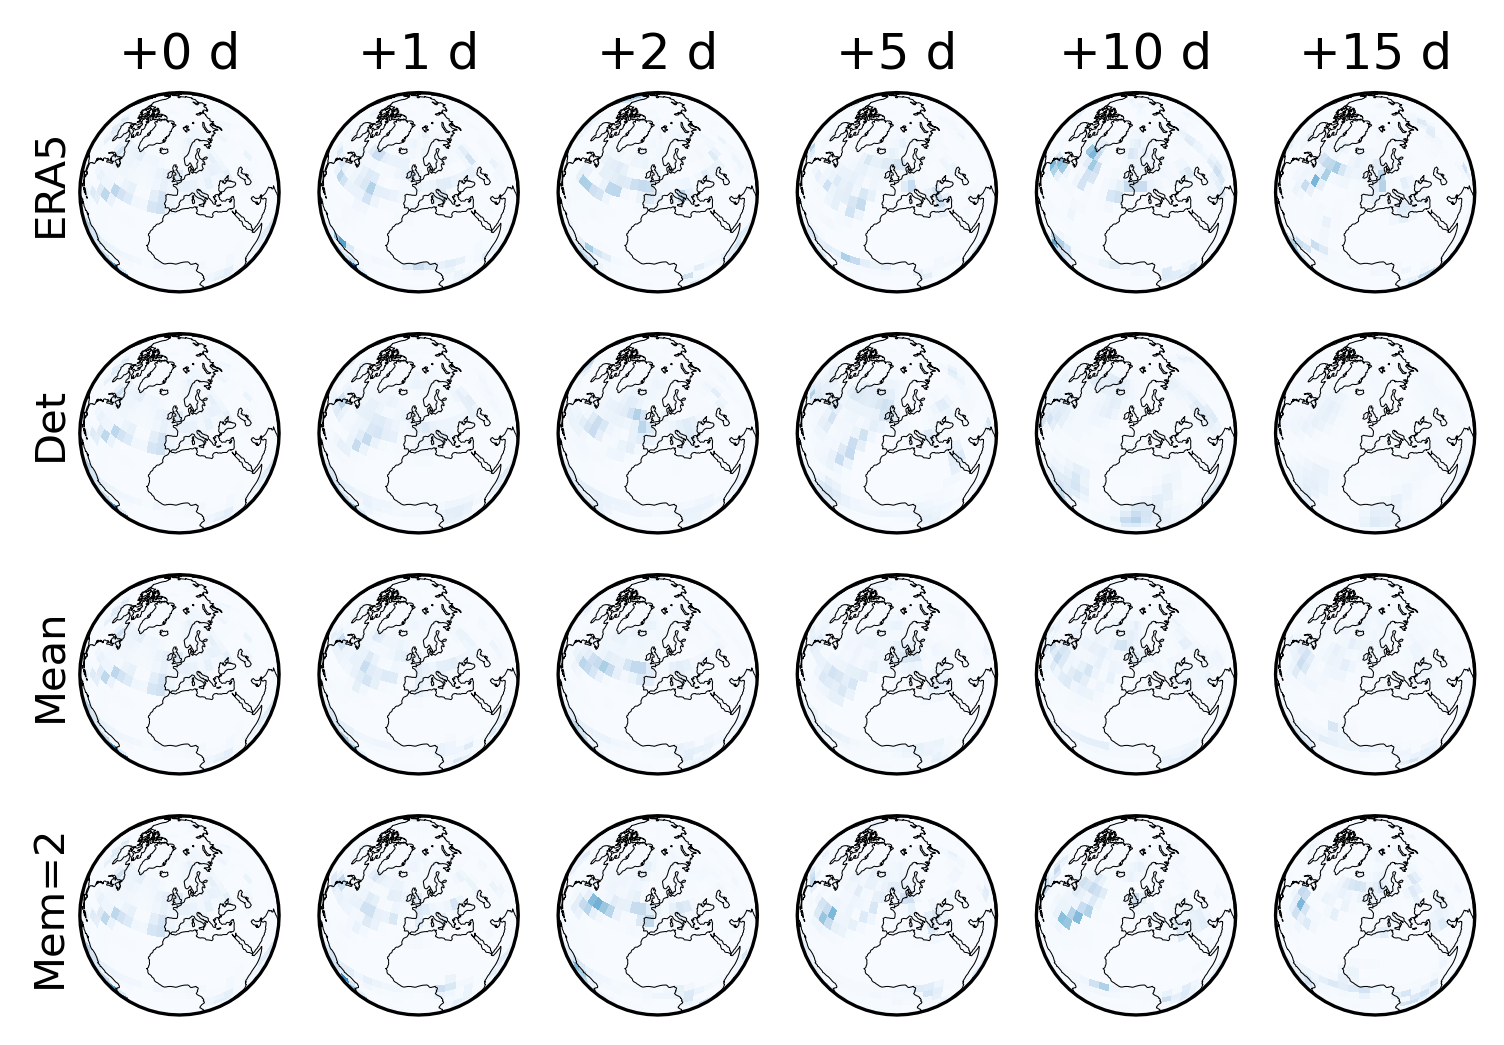

In [67]:
fig, ax = plt.subplots(
    ncols=6, nrows=4, figsize=(6, 4),
    subplot_kw={"projection": ccrs.NearsidePerspective(central_latitude=45)},
    dpi=300
)
for axi in ax:
    for axij in axi:
        axij.xaxis.set_visible(False)
        axij.yaxis.set_visible(False)
        axij.set_yticks([])
        axij.spines.left.set_visible(False)
        axij.spines.right.set_visible(False)
        axij.spines.bottom.set_visible(False)
        #axij.set_extent([-2_500_000, 2_000_000, -2_000_000, 2_500_000], ccrs.NorthPolarStereo())
        axij.add_feature(cartopy.feature.COASTLINE, zorder=98, lw=0.25)

ax[0, 0].text(x=-0.25, y=.55, s="ERA5", rotation=90, transform=ax[0, 0].transAxes, ha="left", va="center")
ax[1, 0].text(x=-0.25, y=.55, s="Det", rotation=90, transform=ax[1, 0].transAxes, ha="left", va="center")
ax[2, 0].text(x=-0.25, y=.55, s="Mean", rotation=90, transform=ax[2, 0].transAxes, ha="left", va="center")
ax[3, 0].text(x=-0.25, y=.55, s=f"Mem={member_to_plot+1:d}", rotation=90, transform=ax[3, 0].transAxes, ha="left", va="center")

for i, td in enumerate([0, 4, 8, 20, 40, 60]):
    ax[0, i].set_title("+{0:d} d".format(td//4))
    ax[0, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], sliced_truth[td, 6].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )
    ax[1, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], det_prediction[td, 6].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )
    ax[2, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[:, td, 6].mean(axis=0).T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )
    ax[3, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[member_to_plot, td, 6].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )